# Coffee Survey Analysis for Milk Alternative Pricing

In this project, I use consumer survey data to study customer preferences for dairy and non-dairy milk options in coffee.

The goal is to understand how much customers are willing to pay, how milk preferences differ across age groups, and how this can help the business think about pricing for milk alternatives such as oat, almond, and soy milk.

## Business Problem

Percolate & Pour wants to understand whether customers who choose non-dairy milk alternatives may be willing to pay more for their coffee.

This is important because the company is considering a price adjustment for milk alternatives such as oat, almond, and soy milk.

To support this decision, I will analyze customer survey data and compare willingness to pay across milk preference groups and age groups.

## Import Libraries

First, I import the main libraries needed for data analysis and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Dataset

Next, I load the survey dataset into pandas so I can inspect and clean it before analysis.

In [2]:
from google.colab import files

In [3]:
uploaded = files.upload()

Saving GACTT_RESULTS_ANONYMIZED.csv to GACTT_RESULTS_ANONYMIZED (1).csv


## First, Let Us Understand the Dataset

Before doing the analysis, it is important to first understand the dataset.

In this step, I check:
- the first few rows
- the number of rows and columns
- the column names and data types

This helps me see what information is available and which columns are useful for the project.

In [4]:
coffee_data = pd.read_csv("GACTT_RESULTS_ANONYMIZED.csv")
coffee_data.head()

,Submission ID,Respondent ID,Submitted at,What is your age?,What is your ZIP code?,How many cups of coffee do you typically drink per day?,Where do you typically drink coffee?,Where do you typically drink coffee? (At home),Where do you typically drink coffee? (At the office),Where do you typically drink coffee? (On the go),...,Gender,Gender (please specify),Marital Status,Household Income,Education Level,Ethnicity/Race,Ethnicity/Race (please specify),Employment Status,Number of Children,Political Affiliation
0,gMR29l,vDzkBA,9/11/23 20:50,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BkPN0e,9Z4VME,9/11/23 20:52,25-34 years old,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,W5G8jj,XoNLQj,9/12/23 1:33,25-34 years old,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4xWgGr,Gp7gde,9/12/23 12:58,35-44 years old,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,QD27Q8,Bp9ogQ,9/12/23 15:24,25-34 years old,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
coffee_data.shape

(4042, 118)

In [6]:
coffee_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4042 entries, 0 to 4041
Columns: 118 entries, Submission ID to Political Affiliation
dtypes: float64(21), object(97)
memory usage: 3.6+ MB


## Check Missing Values

Now I check whether there are any missing values in the columns I may use for the analysis.

In [7]:
coffee_data.isnull().sum()

,0
Submission ID,0
Respondent ID,0
Submitted at,0
What is your age?,31
What is your ZIP code?,78
...,...
Ethnicity/Race,624
Ethnicity/Race (please specify),3937
Employment Status,623
Number of Children,3186


## Select Important Columns

The full survey dataset contains many columns, but for this project I only focus on the columns related to:

- age
- household income
- willingness to pay
- milk preference
- monthly coffee spending

In [8]:
[col for col in coffee_data.columns if "dairy" in col.lower() or "milk" in col.lower() or "creamer" in col.lower()]

['Do you usually add anything to your coffee? (Milk, dairy alternative, or coffee creamer)',
 'What kind of dairy do you add?',
 'What kind of dairy do you add? (Whole milk)',
 'What kind of dairy do you add? (Skim milk)',
 'What kind of dairy do you add? (Half and half)',
 'What kind of dairy do you add? (Coffee creamer)',
 'What kind of dairy do you add? (Flavored coffee creamer)',
 'What kind of dairy do you add? (Oat milk)',
 'What kind of dairy do you add? (Almond milk)',
 'What kind of dairy do you add? (Soy milk)',
 'What kind of dairy do you add? (Other)']

In [9]:
important_columns = [
    "What is your age?",
    "Household Income",
    "What is the most you'd ever be willing to pay for a cup of coffee?",
    "In total, much money do you typically spend on coffee in a month?",
    "What kind of dairy do you add? (Whole milk)",
    "What kind of dairy do you add? (Skim milk)",
    "What kind of dairy do you add? (Half and half)",
    "What kind of dairy do you add? (Coffee creamer)",
    "What kind of dairy do you add? (Flavored coffee creamer)",
    "What kind of dairy do you add? (Oat milk)",
    "What kind of dairy do you add? (Almond milk)",
    "What kind of dairy do you add? (Soy milk)"
]

coffee_selected = coffee_data[important_columns].copy()
coffee_selected.head()

,What is your age?,Household Income,What is the most you'd ever be willing to pay for a cup of coffee?,"In total, much money do you typically spend on coffee in a month?",What kind of dairy do you add? (Whole milk),What kind of dairy do you add? (Skim milk),What kind of dairy do you add? (Half and half),What kind of dairy do you add? (Coffee creamer),What kind of dairy do you add? (Flavored coffee creamer),What kind of dairy do you add? (Oat milk),What kind of dairy do you add? (Almond milk),What kind of dairy do you add? (Soy milk)
0,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,25-34 years old,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,25-34 years old,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,35-44 years old,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,25-34 years old,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Rename the Columns

The original survey column names are long, so I rename the main columns into shorter and clearer names.

This makes the next steps easier to read and work with.

In [10]:
coffee_selected = coffee_selected.rename(columns={
    "What is your age?": "Age_Group",
    "Household Income": "Income",
    "What is the most you'd ever be willing to pay for a cup of coffee?": "Willingness_To_Pay",
    "In total, much money do you typically spend on coffee in a month?": "Monthly_Coffee_Spend",
    "What kind of dairy do you add? (Whole milk)": "Whole_Milk",
    "What kind of dairy do you add? (Skim milk)": "Skim_Milk",
    "What kind of dairy do you add? (Half and half)": "Half_And_Half",
    "What kind of dairy do you add? (Coffee creamer)": "Coffee_Creamer",
    "What kind of dairy do you add? (Flavored coffee creamer)": "Flavored_Coffee_Creamer",
    "What kind of dairy do you add? (Oat milk)": "Oat_Milk",
    "What kind of dairy do you add? (Almond milk)": "Almond_Milk",
    "What kind of dairy do you add? (Soy milk)": "Soy_Milk"
})

coffee_selected.head()

,Age_Group,Income,Willingness_To_Pay,Monthly_Coffee_Spend,Whole_Milk,Skim_Milk,Half_And_Half,Coffee_Creamer,Flavored_Coffee_Creamer,Oat_Milk,Almond_Milk,Soy_Milk
0,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,25-34 years old,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,25-34 years old,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,35-44 years old,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,25-34 years old,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Clean the Willingness to Pay Column

The willingness to pay column is important for this project, so I inspect it first and then clean it if needed.

This helps make sure the calculations are based on usable numeric values.

In [11]:
coffee_selected["Willingness_To_Pay"].head(10)

,Willingness_To_Pay
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
5,NaN
6,NaN
7,NaN
8,NaN
9,NaN


In [12]:
coffee_selected["Willingness_To_Pay"].isnull().sum()

np.int64(532)

## Check the Valid Willingness to Pay Values

Before cleaning the `Willingness_To_Pay` column, I first check how many valid responses are available and what the non-missing values look like.

This helps me understand whether the column contains usable values or whether it needs extra cleaning.

In [13]:
coffee_selected["Willingness_To_Pay"].notnull().sum()
coffee_selected.loc[coffee_selected["Willingness_To_Pay"].notnull(), "Willingness_To_Pay"].head(10)

,Willingness_To_Pay
34,$8-$10
41,More than $20
42,More than $20
43,$15-$20
46,$4-$6
47,$8-$10
48,$6-$8
51,$8-$10
53,$4-$6
54,$8-$10


## Convert Willingness to Pay into Numeric Values

The `Willingness_To_Pay` column is stored as price ranges instead of numeric values.

To make it usable for analysis, I convert each price range into a single representative number using the midpoint of the range.

For example:
- `$4-$6` becomes `5`
- `$6-$8` becomes `7`
- `$8-$10` becomes `9`

For the response `More than $20`, I use `22` as a simple estimated value.

In [14]:
wtp_map = {
    "$4-$6": 5,
    "$6-$8": 7,
    "$8-$10": 9,
    "$10-$15": 12.5,
    "$15-$20": 17.5,
    "More than $20": 22
}

coffee_selected["Willingness_To_Pay_Num"] = coffee_selected["Willingness_To_Pay"].map(wtp_map)

coffee_selected[["Willingness_To_Pay", "Willingness_To_Pay_Num"]].head(10)

,Willingness_To_Pay,Willingness_To_Pay_Num
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
5,NaN,NaN
6,NaN,NaN
7,NaN,NaN
8,NaN,NaN
9,NaN,NaN


## Check the Converted Values

The first few rows still show missing values because those survey responses did not answer the willingness to pay question.

So instead of looking at the first rows of the full table, I now check only the rows that have valid converted values.

In [15]:
coffee_selected.loc[
    coffee_selected["Willingness_To_Pay_Num"].notnull(),
    ["Willingness_To_Pay", "Willingness_To_Pay_Num"]
].head(10)

,Willingness_To_Pay,Willingness_To_Pay_Num
34,$8-$10,9.0
41,More than $20,22.0
42,More than $20,22.0
43,$15-$20,17.5
46,$4-$6,5.0
47,$8-$10,9.0
48,$6-$8,7.0
51,$8-$10,9.0
53,$4-$6,5.0
54,$8-$10,9.0


## Keep Only Valid Willingness to Pay Responses

Now I remove the rows where the numeric willingness to pay value is still missing.

This helps make sure the later calculations are based only on valid responses.

In [16]:
coffee_selected = coffee_selected.dropna(subset=["Willingness_To_Pay_Num"])

coffee_selected[["Willingness_To_Pay", "Willingness_To_Pay_Num"]].head()

,Willingness_To_Pay,Willingness_To_Pay_Num
34,$8-$10,9.0
41,More than $20,22.0
42,More than $20,22.0
43,$15-$20,17.5
46,$4-$6,5.0


## Group Customers into Dairy and Non-Dairy

To compare customer behavior more clearly, I now group milk choices into two main categories:

- **Dairy**
- **Non-Dairy**

This will make it easier to compare willingness to pay between the two groups.

In [17]:
coffee_selected["Dairy_Choice"] = (
    coffee_selected[["Whole_Milk", "Skim_Milk", "Half_And_Half", "Coffee_Creamer", "Flavored_Coffee_Creamer"]]
    .notnull()
    .any(axis=1)
)

coffee_selected["Non_Dairy_Choice"] = (
    coffee_selected[["Oat_Milk", "Almond_Milk", "Soy_Milk"]]
    .notnull()
    .any(axis=1)
)

## Create the Final Milk Group

Now I create one final column called `Milk_Group` so that each customer can be placed into either the **Dairy** or **Non-Dairy** category.

This will be the main grouping variable used in the analysis.

In [18]:
coffee_selected["Milk_Group"] = np.where(
    coffee_selected["Non_Dairy_Choice"], "Non-Dairy",
    np.where(coffee_selected["Dairy_Choice"], "Dairy", "Unknown")
)

coffee_selected["Milk_Group"].value_counts()

,count
Milk_Group,
Unknown,1938
Non-Dairy,1470


## Keep Only Dairy and Non-Dairy Groups

For this project, I only focus on customers who can be clearly grouped into either **Dairy** or **Non-Dairy**.

This helps keep the comparison clean and easier to interpret.

In [19]:
coffee_final = coffee_selected[coffee_selected["Milk_Group"].isin(["Dairy", "Non-Dairy"])].copy()

coffee_final["Milk_Group"].value_counts()

,count
Milk_Group,
Non-Dairy,1470


## Check the Dairy Columns

Before continuing, I want to check whether the dairy-related columns actually contain usable values.

This helps me confirm whether the grouping logic is working correctly.

In [20]:
coffee_selected[["Whole_Milk", "Skim_Milk", "Half_And_Half", "Coffee_Creamer", "Flavored_Coffee_Creamer"]].notnull().sum()

,0
Whole_Milk,1470
Skim_Milk,1470
Half_And_Half,1470
Coffee_Creamer,1470
Flavored_Coffee_Creamer,1470


## Check the Actual Milk Choice Values

The dairy columns are not missing, but that does not automatically mean the customer selected those options.

So before creating the final milk groups, I need to look at the actual values stored in these columns.

In [21]:
coffee_selected[["Whole_Milk", "Skim_Milk", "Half_And_Half", "Coffee_Creamer", "Flavored_Coffee_Creamer",
                 "Oat_Milk", "Almond_Milk", "Soy_Milk"]].head(10)

,Whole_Milk,Skim_Milk,Half_And_Half,Coffee_Creamer,Flavored_Coffee_Creamer,Oat_Milk,Almond_Milk,Soy_Milk
34,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,True,False,False,False,False,False,False,False
47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,False,False,True,False,False,False,False,False
51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53,False,False,False,False,False,True,False,True
54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Rebuild the Milk Groups Using True Values

Now that I can see the milk columns contain `True`, `False`, and `NaN`, I rebuild the dairy and non-dairy groups using only the `True` values.

This is more accurate because it only treats a milk type as selected when the response is actually marked as `True`.

In [22]:
coffee_selected["Dairy_Choice"] = (
    coffee_selected[["Whole_Milk", "Skim_Milk", "Half_And_Half", "Coffee_Creamer", "Flavored_Coffee_Creamer"]]
    .eq(True)
    .any(axis=1)
)

coffee_selected["Non_Dairy_Choice"] = (
    coffee_selected[["Oat_Milk", "Almond_Milk", "Soy_Milk"]]
    .eq(True)
    .any(axis=1)
)

## Create the Final Milk Group Again

After rebuilding the dairy and non-dairy indicators, I now create the final `Milk_Group` column again.

This will allow me to clearly separate customers into the two main groups needed for the analysis.

In [23]:
coffee_selected["Milk_Group"] = np.where(
    coffee_selected["Non_Dairy_Choice"], "Non-Dairy",
    np.where(coffee_selected["Dairy_Choice"], "Dairy", "Unknown")
)

coffee_selected["Milk_Group"].value_counts()

,count
Milk_Group,
Unknown,1948
Dairy,923
Non-Dairy,537


## Keep Only Dairy and Non-Dairy Groups

For the main analysis, I only keep the customers who can be clearly grouped into either **Dairy** or **Non-Dairy**.

This makes the comparison more focused and easier to interpret.

In [24]:
coffee_final = coffee_selected[coffee_selected["Milk_Group"].isin(["Dairy", "Non-Dairy"])].copy()

coffee_final["Milk_Group"].value_counts()

,count
Milk_Group,
Dairy,923
Non-Dairy,537


## Compare Mean and Median Willingness to Pay

Now I calculate the mean and median willingness to pay for the Dairy and Non-Dairy groups.

This helps show whether customers who prefer milk alternatives may be willing to pay more for their coffee.

In [25]:
wtp_summary = coffee_final.groupby("Milk_Group")["Willingness_To_Pay_Num"].agg(["mean", "median"])
wtp_summary

,mean,median
Milk_Group,,
Dairy,11.143554,9.0
Non-Dairy,11.229050,9.0


## Cross-Tabulation of Age Group and Milk Preference

Next, I compare age groups and milk preference to see how the Dairy and Non-Dairy groups are distributed across different age categories.

This helps identify which age groups are more connected to milk alternative choices.

In [26]:
age_milk_table = pd.crosstab(coffee_final["Age_Group"], coffee_final["Milk_Group"])
age_milk_table

Milk_Group,Dairy,Non-Dairy
Age_Group,,
18-24 years old,109,55
25-34 years old,406,301
35-44 years old,239,123
45-54 years old,79,34
55-64 years old,59,15
<18 years old,7,2
>65 years old,24,7


## Find the Largest Age Group for Oat Milk

The project also asks to identify the largest demographic for oat milk.

To do that, I now focus only on the customers who selected oat milk and count how many belong to each age group.

In [27]:
oat_milk_data = coffee_selected[coffee_selected["Oat_Milk"] == True].copy()

oat_milk_data["Age_Group"].value_counts()

,count
Age_Group,
25-34 years old,262
35-44 years old,105
18-24 years old,49
45-54 years old,16
55-64 years old,9
>65 years old,3
<18 years old,1


## Visualization 1: Average Willingness to Pay by Milk Group

This bar chart compares the average willingness to pay for customers in the Dairy and Non-Dairy groups.

It helps show whether customers who prefer milk alternatives may be willing to pay slightly more for their coffee.

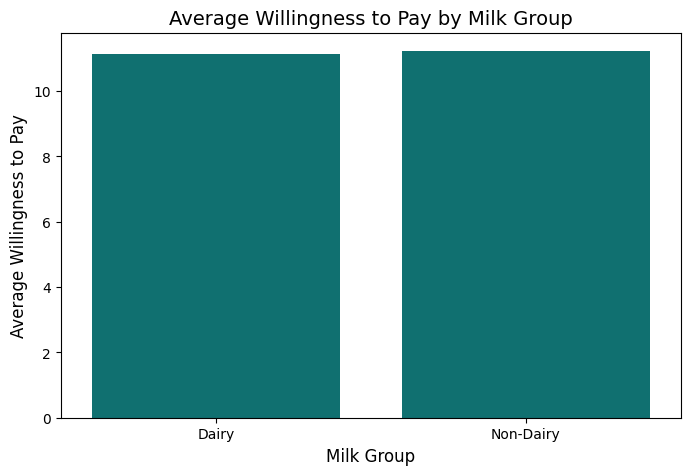

In [28]:
average_wtp = coffee_final.groupby("Milk_Group")["Willingness_To_Pay_Num"].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=average_wtp, x="Milk_Group", y="Willingness_To_Pay_Num", color="teal")

plt.title("Average Willingness to Pay by Milk Group", fontsize=14)
plt.xlabel("Milk Group", fontsize=12)
plt.ylabel("Average Willingness to Pay", fontsize=12)

plt.show()

## Visualization 2: Willingness to Pay Across Age Groups

Next, I create a box plot to show how willingness to pay is distributed across different age groups.

This helps identify differences in spending patterns and also makes it easier to spot possible high-spending outliers.

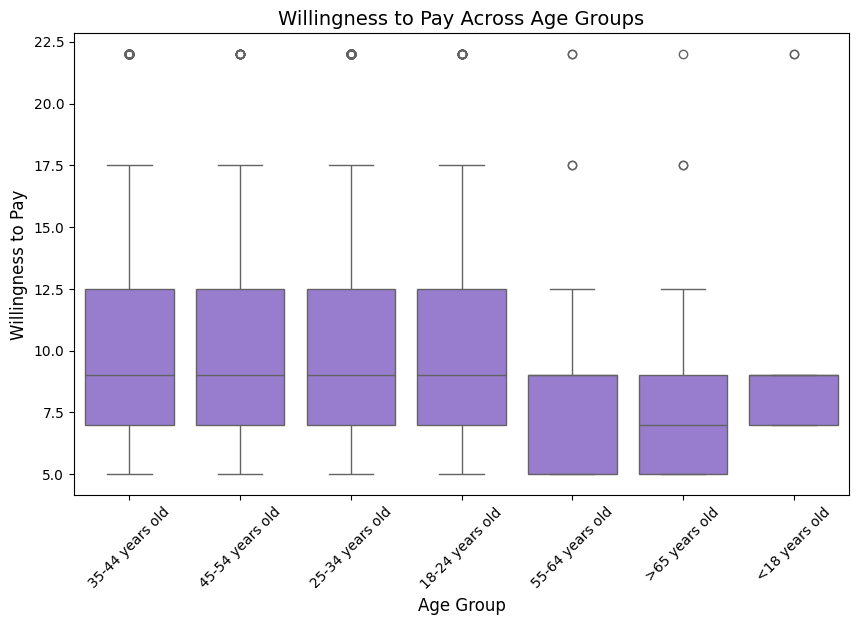

In [29]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=coffee_final, x="Age_Group", y="Willingness_To_Pay_Num", color="mediumpurple")

plt.title("Willingness to Pay Across Age Groups", fontsize=14)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Willingness to Pay", fontsize=12)
plt.xticks(rotation=45)

plt.show()

## Calculate the Maximum Viable Surcharge

To estimate a possible surcharge for milk alternatives, I use the **75th percentile** of willingness to pay for the Non-Dairy group.

This gives a practical upper range that many non-dairy customers may still be willing to accept.

In [30]:
non_dairy_wtp = coffee_final[coffee_final["Milk_Group"] == "Non-Dairy"]["Willingness_To_Pay_Num"]

maximum_viable_surcharge = non_dairy_wtp.quantile(0.75)

print("Maximum Viable Surcharge:", round(maximum_viable_surcharge, 2))

Maximum Viable Surcharge: 12.5


## Final Summary

From this analysis, I found that customers in the Non-Dairy group had a slightly higher average willingness to pay than customers in the Dairy group, although the difference was small.

I also found that the **25–34 years old** group was the largest age group for oat milk.

The visualizations showed that willingness to pay is fairly similar across milk groups and age groups, but there are still some higher-paying outliers in the data.

Using the **75th percentile** of willingness to pay for the Non-Dairy group, I estimated a **Maximum Viable Surcharge** for milk alternatives. This gives a practical upper range that the business can consider when thinking about a price adjustment.

Overall, the results suggest that a small surcharge for non-dairy milk may be reasonable, but the difference in willingness to pay is not large enough to support a very high price increase.

In [31]:
summary_table = pd.DataFrame({
    "Metric": [
        "Average WTP - Dairy",
        "Average WTP - Non-Dairy",
        "Median WTP - Dairy",
        "Median WTP - Non-Dairy",
        "Largest Age Group for Oat Milk",
        "Maximum Viable Surcharge"
    ],
    "Value": [
        round(coffee_final[coffee_final["Milk_Group"] == "Dairy"]["Willingness_To_Pay_Num"].mean(), 2),
        round(coffee_final[coffee_final["Milk_Group"] == "Non-Dairy"]["Willingness_To_Pay_Num"].mean(), 2),
        round(coffee_final[coffee_final["Milk_Group"] == "Dairy"]["Willingness_To_Pay_Num"].median(), 2),
        round(coffee_final[coffee_final["Milk_Group"] == "Non-Dairy"]["Willingness_To_Pay_Num"].median(), 2),
        "25-34 years old",
        round(maximum_viable_surcharge, 2)
    ]
})

summary_table

,Metric,Value
0,Average WTP - Dairy,11.14
1,Average WTP - Non-Dairy,11.23
2,Median WTP - Dairy,9.0
3,Median WTP - Non-Dairy,9.0
4,Largest Age Group for Oat Milk,25-34 years old
5,Maximum Viable Surcharge,12.5
